
✅ Time series dataset saved successfully!

🔍 Time Series Dataset Preview:
                 Date  Crime_Count_30D
0 2001-01-01 00:00:00              1.0
1 2001-01-01 00:01:00              9.0
2 2001-01-01 00:10:00              5.0
3 2001-01-01 00:15:00              6.0
4 2001-01-01 00:20:00              7.0
5 2001-01-01 01:00:00             17.0
6 2001-01-01 01:01:44             10.0
7 2001-01-01 01:27:12             11.0
8 2001-01-01 01:55:00             12.0
9 2001-01-01 02:00:00             13.0


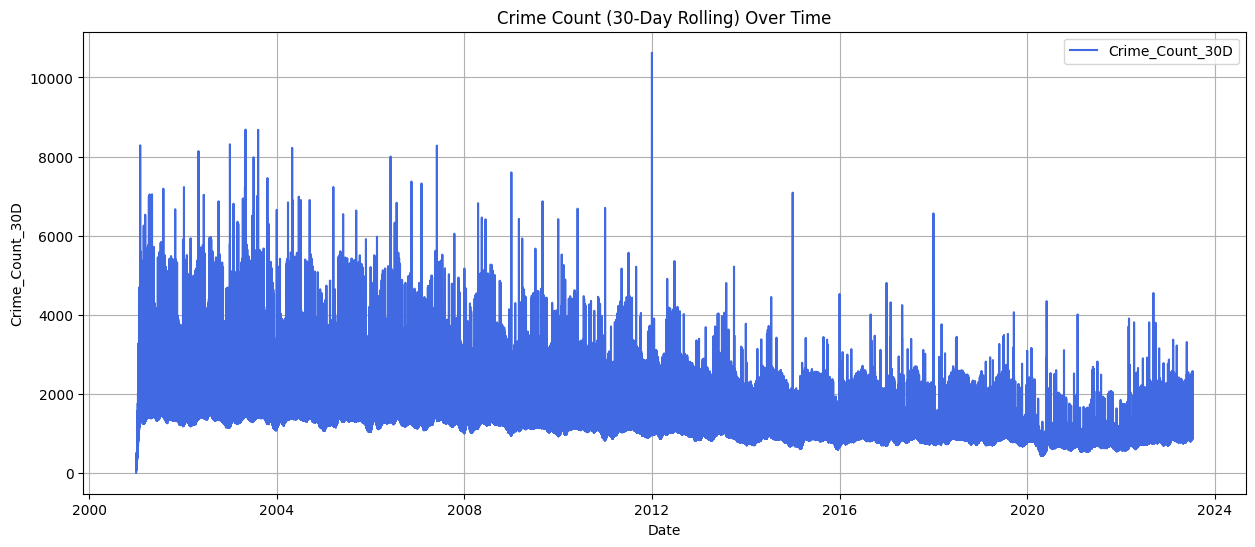

In [2]:
import pandas as pd

# ✅ Load the crime_data_engineered.csv
crime_df = pd.read_csv("crime_data_engineered.csv")

# ✅ Select relevant columns
ts_df = crime_df[['Date', 'Crime_Count_30D']].copy()

# 🔥 Convert 'Date' to datetime format
ts_df['Date'] = pd.to_datetime(ts_df['Date'])

# 🛠️ Aggregate by date (sum Crime_Count_30D for each day)
ts_df = ts_df.groupby('Date').sum().reset_index()

# ✅ Sort by date (to ensure chronological order)
ts_df = ts_df.sort_values('Date')

# ✅ Save the dataset
ts_df.to_csv("crime_time_series.csv", index=False)
print("\n✅ Time series dataset saved successfully!")

# 📊 Display the final dataset
print("\n🔍 Time Series Dataset Preview:")
print(ts_df.head(10))

# 🚀 Visualize the time series
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.plot(ts_df['Date'], ts_df['Crime_Count_30D'], color='royalblue', label='Crime_Count_30D')
plt.title('Crime Count (30-Day Rolling) Over Time')
plt.xlabel('Date')
plt.ylabel('Crime_Count_30D')
plt.grid(True)
plt.legend()
plt.show()


In [3]:
# Apply differencing (1st order differencing)
ts_df['Crime_Count_30D_diff'] = ts_df['Crime_Count_30D'].diff().dropna()

# ✅ Remove NaN values caused by differencing
ts_df = ts_df.dropna()

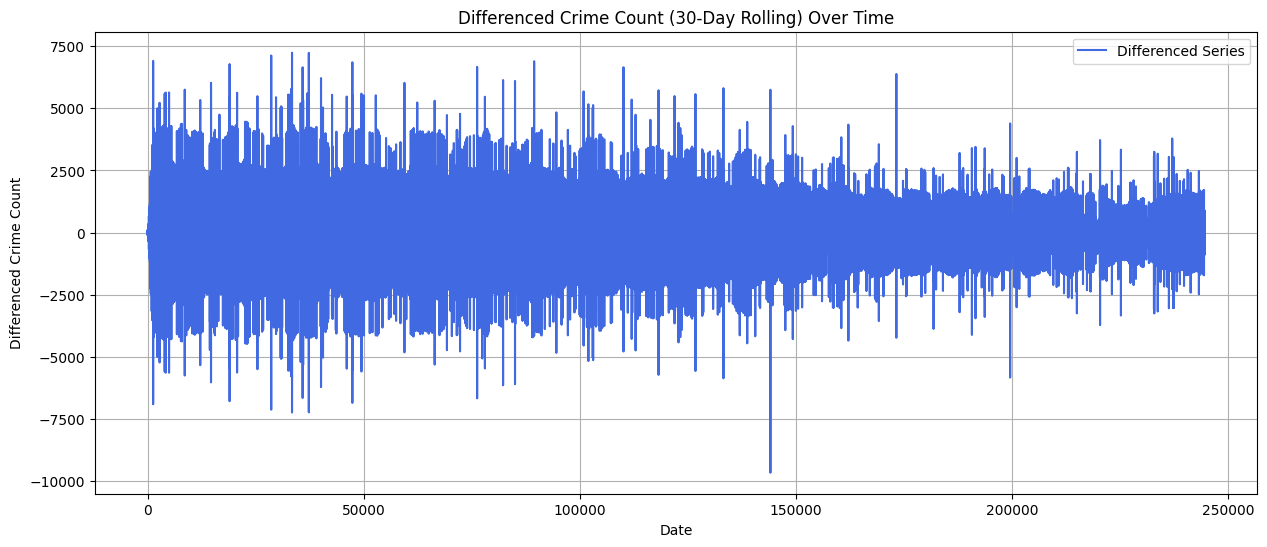

In [4]:
# 📊 Visualize the differenced series
plt.figure(figsize=(15, 6))
plt.plot(ts_df.index, ts_df['Crime_Count_30D_diff'], label='Differenced Series', color='royalblue')
plt.title('Differenced Crime Count (30-Day Rolling) Over Time')
plt.xlabel('Date')
plt.ylabel('Differenced Crime Count')
plt.grid(True)
plt.legend()
plt.show()

In [5]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

# 🔥 ADF Test on the differenced series
result = adfuller(ts_df['Crime_Count_30D_diff'])

# 📌 Display ADF results
print("\n🔥 Augmented Dickey-Fuller Test Results:")
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print(f"Critical Values: {result[4]}")
if result[1] <= 0.05:
    print("\n✅ The series is stationary (p-value <= 0.05)")
else:
    print("\n❌ The series is NOT stationary (p-value > 0.05)")



🔥 Augmented Dickey-Fuller Test Results:
ADF Statistic: -91.1918
p-value: 0.0000
Critical Values: {'1%': np.float64(-3.430376751135884), '5%': np.float64(-2.861551823659946), '10%': np.float64(-2.5667762933070337)}

✅ The series is stationary (p-value <= 0.05)


In [7]:
# ✅ Save the differenced dataset
ts_df[['Date', 'Crime_Count_30D']].to_csv("crime_time_series_diff.csv")
print("\n💾 Differenced stationary dataset saved successfully!")


💾 Differenced stationary dataset saved successfully!
